<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Scatter Plot**


Estimated time needed: **45** minutes


## Overview

In this lab, you will focus on creating and interpreting scatter plots to visualize relationships between variables and trends in the dataset. The provided dataset will be directly loaded into a pandas DataFrame, and various scatter plot-related visualizations will be created to explore developer trends, compensation, and preferences.



## Objectives


In this lab, you will:

- Create and analyze scatter plots to examine relationships between variables.

- Use scatter plots to identify trends and patterns in the dataset.

- Focus on visualizations centered on scatter plots for better data-driven insights.


## Setup: Working with the Database



**Install and import the required libraries**


In [1]:
#!pip install pandas
#!pip install matplotlib

import pandas as pd
import matplotlib.pyplot as plt

#### Step 1: Load the dataset


In [2]:
file_path = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"

df = pd.read_csv(file_path)



### Task 1: Exploring Relationships with Scatter Plots



#### 1. Scatter Plot for Age vs. Job Satisfaction



Visualize the relationship between respondents' age (`Age`) and job satisfaction (`JobSatPoints_6`). Use this plot to identify any patterns or trends.




In [3]:
df_age_jobsat = df[['Age', 'JobSatPoints_6']].dropna()
df_age_jobsat = df_age_jobsat.sort_values(['Age']) # sort values for readability along x-axis
df_age_jobsat.head()

,Age,JobSatPoints_6
72,18-24 years old,65.0
77,18-24 years old,8.0
98,18-24 years old,15.0
110,18-24 years old,20.0
117,18-24 years old,0.0


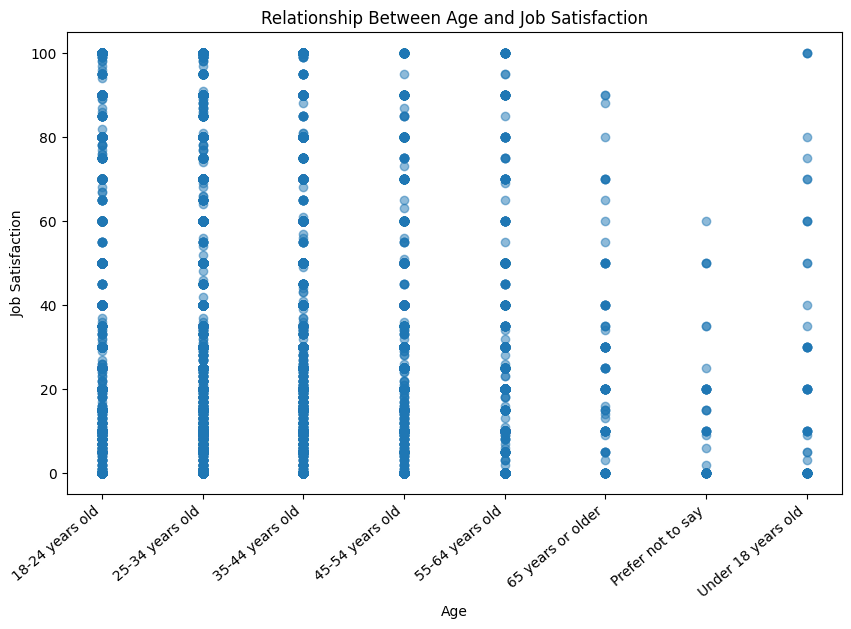

In [4]:
plt.figure(figsize = (10, 6))
plt.scatter(x = df_age_jobsat['Age'], y = df_age_jobsat['JobSatPoints_6'], alpha = 0.5)
plt.xlabel('Age')
plt.ylabel('Job Satisfaction')
plt.title('Relationship Between Age and Job Satisfaction')
plt.xticks(rotation = 40, ha = 'right')
plt.show()

#### 2. Scatter Plot for Compensation vs. Job Satisfaction


Explore the relationship between yearly compensation (`ConvertedCompYearly`) and job satisfaction (`JobSatPoints_6`) using a scatter plot.


In [5]:
df_comp_sat = df[['ConvertedCompYearly', 'JobSatPoints_6']]
df_comp_sat = df_comp_sat.dropna()
df_comp_sat = df_comp_sat.sort_values('JobSatPoints_6') # sort values for ordered numbering along plotted x axis

q1 = df_comp_sat['ConvertedCompYearly'].quantile(0.25)
q3 = df_comp_sat['ConvertedCompYearly'].quantile(0.75)
iqr = q3 - q1
upper_bounds = (iqr * 1.5) + q3
df_comp_sat = df_comp_sat[df_comp_sat['ConvertedCompYearly'] <= upper_bounds]
df_comp_sat.head()

,ConvertedCompYearly,JobSatPoints_6
548,13160.0,0.0
542,3618.0,0.0
530,85925.0,0.0
497,14142.0,0.0
26585,76328.0,0.0


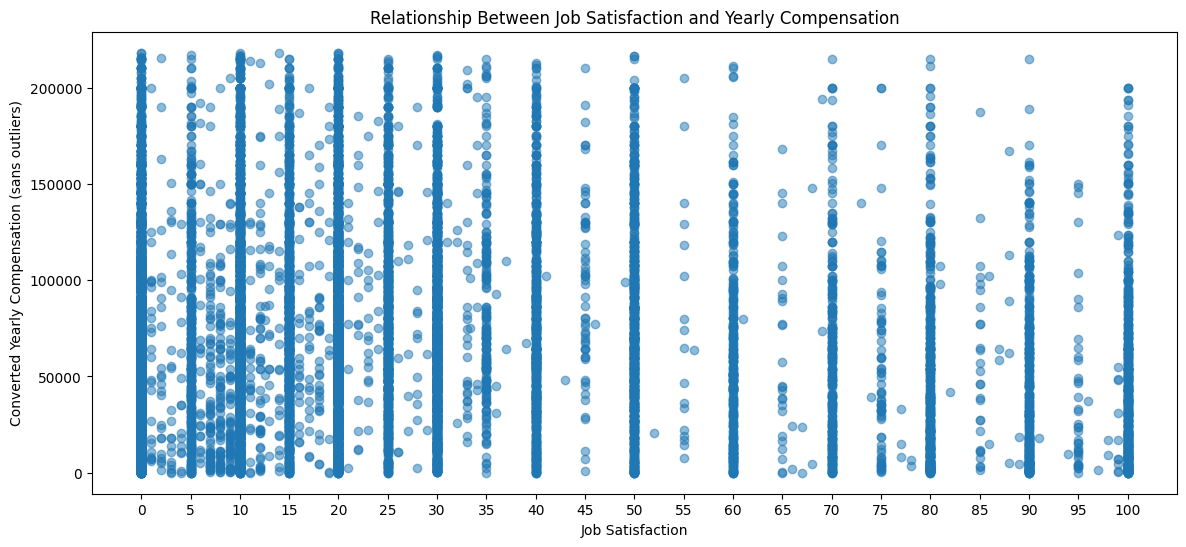

In [6]:
plt.figure(figsize = (14,6))
plt.scatter(x = df_comp_sat['JobSatPoints_6'], y = df_comp_sat['ConvertedCompYearly'], alpha = 0.5)
plt.xticks(ticks = range(0, 101, 5))
plt.xlabel('Job Satisfaction')
plt.ylabel('Converted Yearly Compensation (sans outliers)')
plt.title('Relationship Between Job Satisfaction and Yearly Compensation')
plt.show()

### Task 2: Enhancing Scatter Plots


#### 1. Scatter Plot with Trend Line for Age vs. Job Satisfaction



Add a regression line to the scatter plot of Age vs. JobSatPoints_6 to highlight trends in the data.


In [7]:
df_age_jobsat = df_age_jobsat[df_age_jobsat['Age'].str.contains('Prefer not to say')==False] # dropping values that cannot be interpreted numerically

df_age_jobsat['Age'] = df_age_jobsat['Age'].map({'Under 18 years old': 16,
                                                 '65 years or older': 67,
                                                 '25-34 years old': 29,
                                                 '35-44 years old': 39,
                                                 '18-24 years old': 21,
                                                 '45-54 years old': 49,
                                                 '55-64 years old': 60})

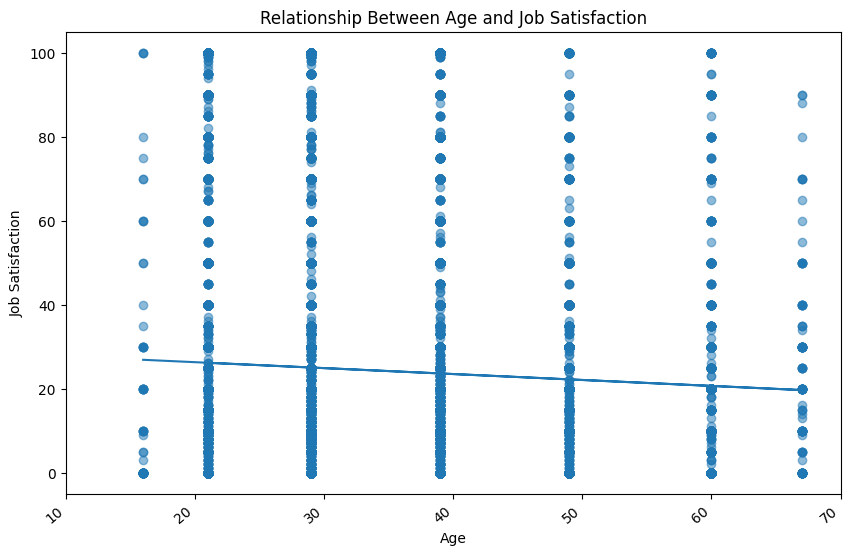

In [8]:
import numpy as np

x = df_age_jobsat['Age']
y = df_age_jobsat['JobSatPoints_6']

m, b = np.polyfit(x, y, 1)


plt.figure(figsize = (10, 6))
plt.scatter(x = x, y = y, alpha = 0.5)
plt.plot(x, m * x + b)
plt.xlabel('Age')
plt.ylabel('Job Satisfaction')
plt.title('Relationship Between Age and Job Satisfaction')
plt.xticks(ticks = range(10, 71, 10), rotation = 40, ha = 'right')
plt.show()

#### 2. Scatter Plot for Age vs. Work Experience


Visualize the relationship between Age (`Age`) and Work Experience (`YearsCodePro`) using a scatter plot.


In [9]:
df_age_code = df[['Age', 'YearsCodePro']]
df_age_code = df_age_code.dropna()
df_age_code = df_age_code[df_age_code['Age'].str.contains('Prefer not to say')==False] # dropping values that cannot 
                                                                                       # be interpreted numerically

In [10]:
df_age_code[df_age_code['YearsCodePro']=='More than 50 years']

,Age,YearsCodePro
1019,55-64 years old,More than 50 years
1839,65 years or older,More than 50 years
1941,65 years or older,More than 50 years
2632,65 years or older,More than 50 years
4546,65 years or older,More than 50 years
4641,65 years or older,More than 50 years
5889,65 years or older,More than 50 years
6271,65 years or older,More than 50 years
8903,65 years or older,More than 50 years
8938,65 years or older,More than 50 years


In [11]:
# converting to approx numbers for removal of impossibilities
df_age_code['Age'] = df_age_code['Age'].map({'Under 18 years old': 16,
                                             '65 years or older': 67,
                                             '25-34 years old': 29,
                                             '35-44 years old': 39,
                                             '18-24 years old': 21,
                                             '45-54 years old': 49,
                                             '55-64 years old': 60})
df_age_code['YearsCodePro'] = df_age_code['YearsCodePro'].replace({'Less than 1 year': 0, # replacing with numerical values
                                                                   'More than 50 years': 51})
df_age_code['YearsCodePro'] = df_age_code['YearsCodePro'].astype(int) # converting type to int

In [12]:
# some rows contain impossibilities, i.e. years code pro > age
# used 13 as a reasonable age one could have possibly begun professional work
df_age_code = df_age_code.drop(df_age_code[(df_age_code['Age'] - df_age_code['YearsCodePro'] < 13)].index) # removing said rows
df_age_code[df_age_code['YearsCodePro']> 50] # checking the values

,Age,YearsCodePro
1839,67,51
1941,67,51
2632,67,51
4546,67,51
4641,67,51
5889,67,51
6271,67,51
8903,67,51
8938,67,51
9498,67,51


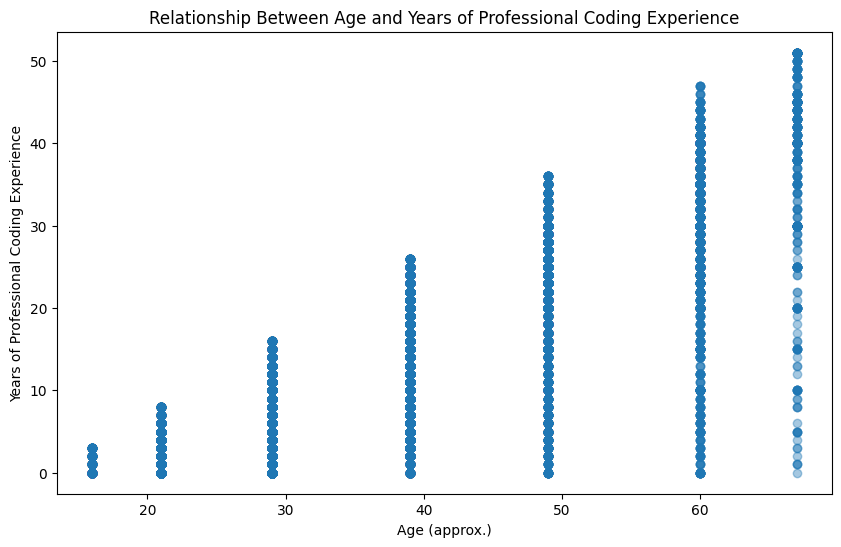

In [13]:
plt.figure(figsize = (10,6))
plt.scatter(x = df_age_code['Age'], y = df_age_code['YearsCodePro'], alpha=0.4)
plt.xlabel('Age (approx.)')
plt.ylabel('Years of Professional Coding Experience')
plt.title('Relationship Between Age and Years of Professional Coding Experience')
plt.show()

### Task 3: Combining Scatter Plots with Additional Features


#### 1. Bubble Plot of Compensation vs. Job Satisfaction with Age as Bubble Size



Create a bubble plot to explore the relationship between yearly compensation (`ConvertedCompYearly`) and job satisfaction (`JobSatPoints_6`), with bubble size representing age.


In [14]:
bub_comp_sat = df[['ConvertedCompYearly', 'JobSatPoints_6', 'Age']].dropna().reset_index(drop = True)
bub_comp_sat.head()

,ConvertedCompYearly,JobSatPoints_6,Age
0,7322.0,65.0,18-24 years old
1,91295.0,0.0,35-44 years old
2,110000.0,20.0,25-34 years old
3,161044.0,30.0,35-44 years old
4,195000.0,30.0,45-54 years old


In [15]:
bub_comp_sat = bub_comp_sat[bub_comp_sat['Age'] != 'Prefer not to say'] # removing non-numerical answers
bub_comp_sat['Age'] = bub_comp_sat['Age'].map({'Under 18 years old': 16, # reassinging strings to approx integers
                                               '65 years or older': 67,
                                               '25-34 years old': 29,
                                               '35-44 years old': 39,
                                               '18-24 years old': 21,
                                               '45-54 years old': 49,
                                               '55-64 years old': 60})
bub_comp_sat['Age'].value_counts() # verifying process

Age
29    7431
39    4377
21    2299
49    1492
60     496
67      55
16      27
Name: count, dtype: int64

In [16]:
q1 = bub_comp_sat['ConvertedCompYearly'].quantile(.25)
q3 = bub_comp_sat['ConvertedCompYearly'].quantile(.75)
iqr = q3 - q1
upper_bounds = (iqr * 1.5) + q3
bub_comp_sat_no_outliers = bub_comp_sat[bub_comp_sat['ConvertedCompYearly'] <= upper_bounds] # new df without outliers
bub_comp_sat_no_outliers.head()

,ConvertedCompYearly,JobSatPoints_6,Age
0,7322.0,65.0,21
1,91295.0,0.0,39
2,110000.0,20.0,29
3,161044.0,30.0,39
4,195000.0,30.0,49


In [17]:
bub_comp_sat_no_outliers = bub_comp_sat_no_outliers.sort_values('Age')

In [18]:
bub_comp_sat_no_outliers['Age'].value_counts().index

Index([29, 39, 21, 49, 60, 67, 16], dtype='int64', name='Age')

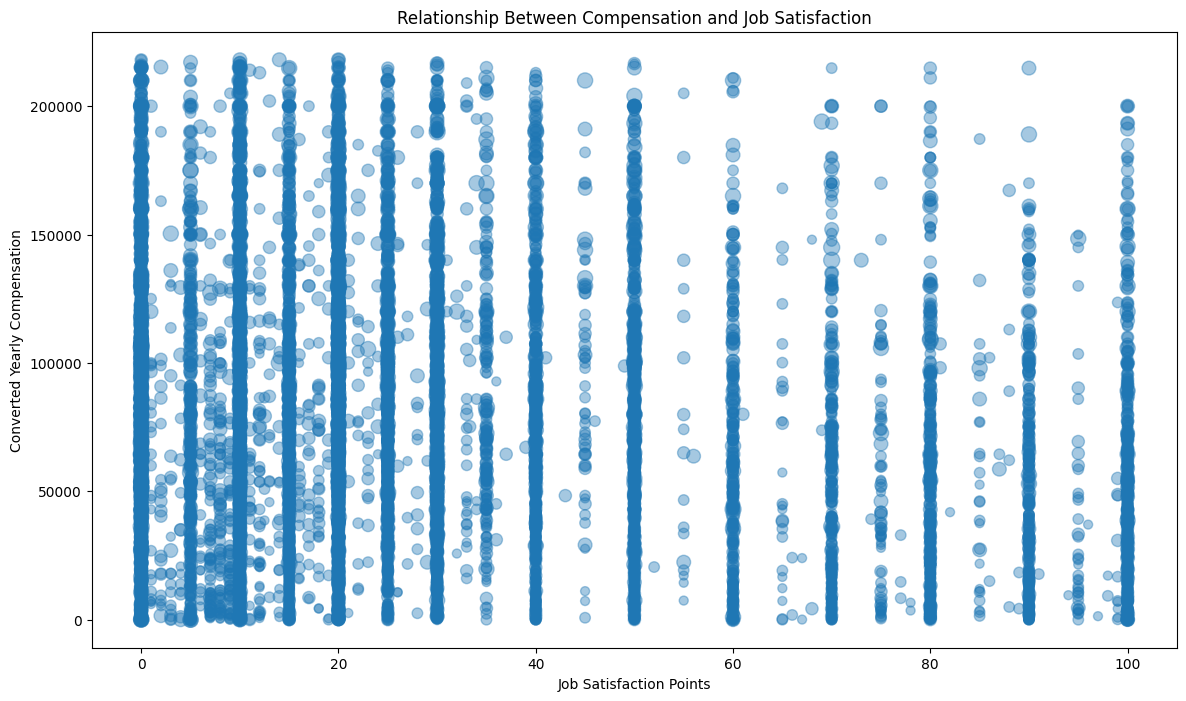

In [19]:
plt.figure(figsize = (14,8))
plt.scatter(bub_comp_sat_no_outliers['JobSatPoints_6'],
            bub_comp_sat_no_outliers['ConvertedCompYearly'],
            s = bub_comp_sat_no_outliers['Age']*2,
            alpha = 0.4)
plt.xlabel('Job Satisfaction Points')
plt.ylabel('Converted Yearly Compensation')
plt.title('Relationship Between Compensation and Job Satisfaction')
#plt.legend([29, 39, 21, 49, 60, 67, 16],
#           bbox_to_anchor= (0.94, 1.01),
#           title='Age')
plt.show()

#### 2. Scatter Plot for Popular Programming Languages by Job Satisfaction


Visualize the popularity of programming languages (`LanguageHaveWorkedWith`) against job satisfaction using a scatter plot. Use points to represent satisfaction levels for each language.


In [20]:
scat_lang_sat = df[['LanguageHaveWorkedWith', 'JobSatPoints_6']]
scat_lang_sat = scat_lang_sat.dropna().reset_index(drop = True)
scat_lang_sat.head()

,LanguageHaveWorkedWith,JobSatPoints_6
0,Bash/Shell (all shells);Go;HTML/CSS;Java;JavaS...,0.0
1,JavaScript;Python;Ruby,25.0
2,Bash/Shell (all shells);C#;JavaScript;PowerShe...,30.0
3,C#;HTML/CSS;JavaScript;PowerShell;SQL;TypeScri...,0.0
4,C#;HTML/CSS;JavaScript;PHP;Python;SQL,60.0


In [21]:
scat_lang = scat_lang_sat['LanguageHaveWorkedWith'].str.split(';').explode() # explode lists in column
scat_lang.head()

0    Bash/Shell (all shells)
0                         Go
0                   HTML/CSS
0                       Java
0                 JavaScript
Name: LanguageHaveWorkedWith, dtype: str

In [22]:
scat_lang_sat_exp = pd.DataFrame(scat_lang) # creating dataframe for exploded data
scat_lang_sat_exp = scat_lang_sat_exp.join(scat_lang_sat['JobSatPoints_6'], # joining jobsat on (repeated) indices from explode function
                                           how = 'left') # to pair score with each language in each row's list
scat_lang_sat_exp = scat_lang_sat_exp.reset_index(drop = True) # resetting index
scat_lang_sat_exp.head(10)

,LanguageHaveWorkedWith,JobSatPoints_6
0,Bash/Shell (all shells),0.0
1,Go,0.0
2,HTML/CSS,0.0
3,Java,0.0
4,JavaScript,0.0
5,Python,0.0
6,TypeScript,0.0
7,JavaScript,25.0
8,Python,25.0
9,Ruby,25.0


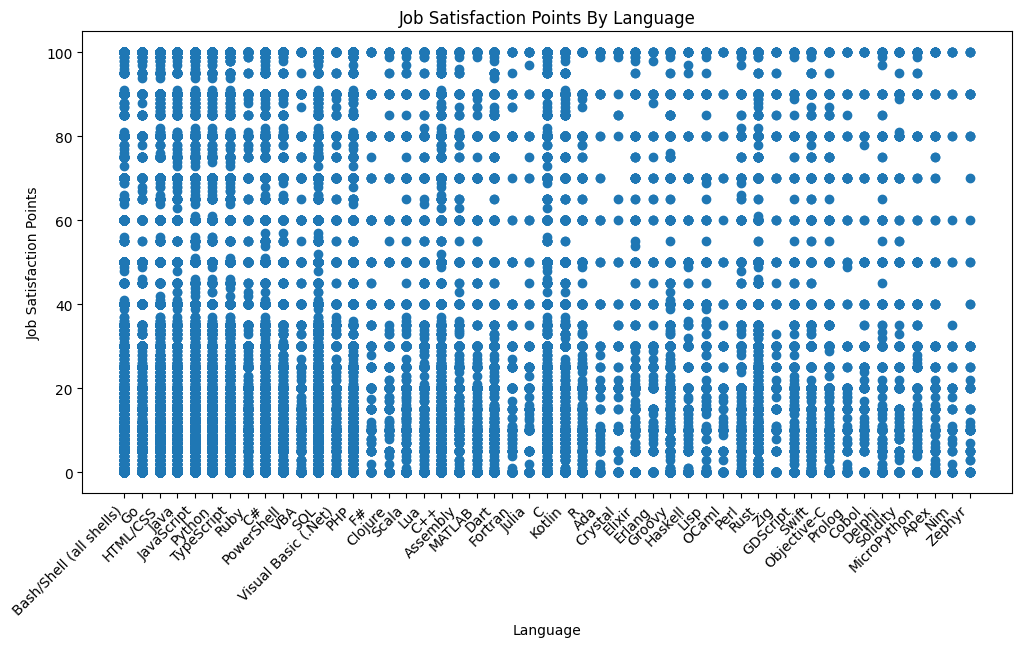

In [23]:
plt.figure(figsize = (12,6))
plt.scatter(x = scat_lang_sat_exp['LanguageHaveWorkedWith'],
            y = scat_lang_sat_exp['JobSatPoints_6'])
plt.title('Job Satisfaction Points By Language')
plt.xlabel('Language')
plt.ylabel('Job Satisfaction Points')
plt.xticks(rotation = 45, ha='right')
plt.show()

### Task 4: Scatter Plot Comparisons Across Groups


#### 1. Scatter Plot for Compensation vs. Job Satisfaction by Employment Type


Visualize the relationship between yearly compensation (`ConvertedCompYearly`) and job satisfaction (`JobSatPoints_6`), categorized by employment type (`Employment`). Use color coding or markers to differentiate between employment types.


In [24]:
scat_comp_sat = df[['ConvertedCompYearly', 'JobSatPoints_6', 'Employment']]
scat_comp_sat = scat_comp_sat.dropna().reset_index(drop = True)

q1 = scat_comp_sat['ConvertedCompYearly'].quantile(.25)
q3 = scat_comp_sat['ConvertedCompYearly'].quantile(.75)
iqr = q3 - q1
upper_bounds = (iqr * 1.5) + q3

scat_comp_sat = scat_comp_sat[scat_comp_sat['ConvertedCompYearly'] < upper_bounds] # removing outliers
scat_comp_sat.head()

,ConvertedCompYearly,JobSatPoints_6,Employment
0,7322.0,65.0,"Employed, full-time;Student, full-time;Indepen..."
1,91295.0,0.0,"Employed, full-time"
2,110000.0,20.0,"Employed, full-time;Student, part-time"
3,161044.0,30.0,"Employed, full-time"
4,195000.0,30.0,"Employed, full-time"


In [25]:
emp_types = scat_comp_sat['Employment'].value_counts().head(10).keys() # acquiring list of top 10 employment types
rows = scat_comp_sat.loc[scat_comp_sat['Employment'].isin(emp_types) == False] # storing rows without the top 10 to remove
scat_comp_sat = scat_comp_sat.drop(rows.index).reset_index(drop = True) # removing the rows according to index
scat_comp_sat.head()

,ConvertedCompYearly,JobSatPoints_6,Employment
0,91295.0,0.0,"Employed, full-time"
1,110000.0,20.0,"Employed, full-time;Student, part-time"
2,161044.0,30.0,"Employed, full-time"
3,195000.0,30.0,"Employed, full-time"
4,79481.0,25.0,"Employed, full-time;Independent contractor, fr..."


In [26]:
labels, uniques = pd.factorize(scat_comp_sat['Employment']) # enumerating the different employment types
legend_elements = dict(zip(uniques, range(0, 10))) # create a dictionary pairing uniques with their labels for legend

legend_elements

{'Employed, full-time': 0,
 'Employed, full-time;Student, part-time': 1,
 'Employed, full-time;Independent contractor, freelancer, or self-employed': 2,
 'Independent contractor, freelancer, or self-employed': 3,
 'Employed, full-time;Student, full-time': 4,
 'Student, part-time;Employed, part-time': 5,
 'Independent contractor, freelancer, or self-employed;Employed, part-time': 6,
 'Employed, part-time': 7,
 'Student, full-time;Employed, part-time': 8,
 'Employed, full-time;Employed, part-time': 9}

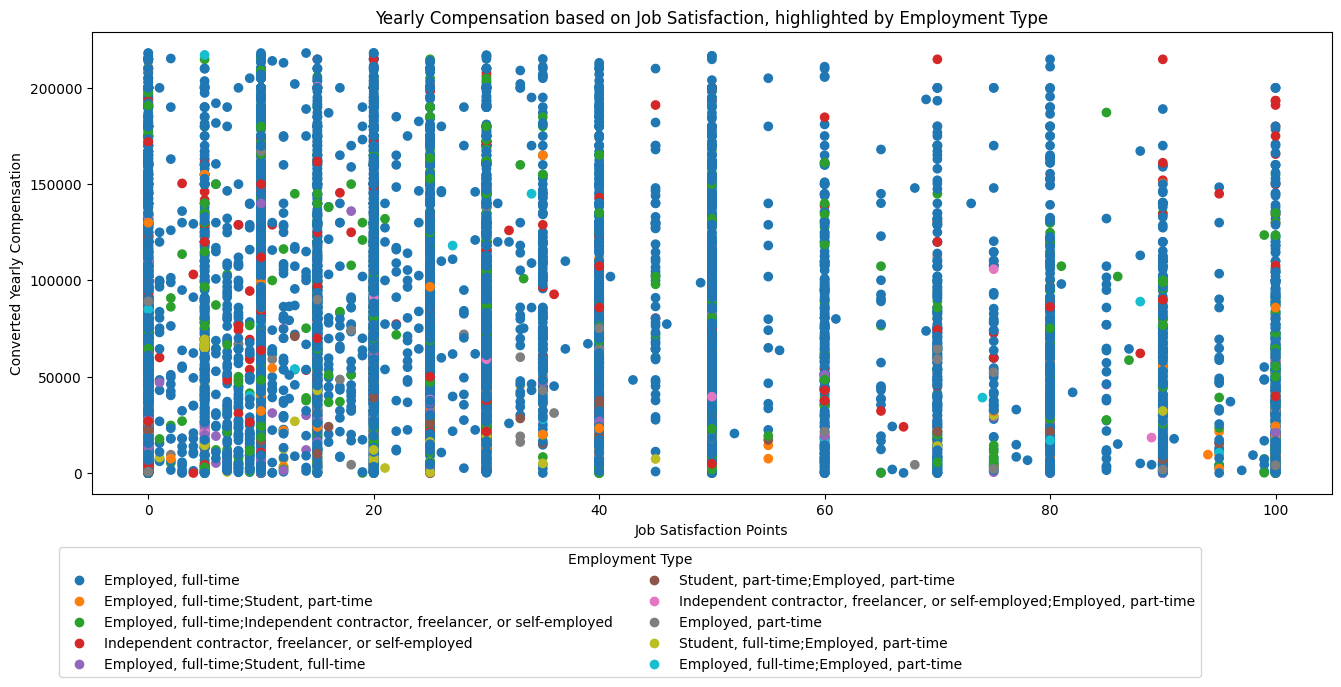

In [27]:

fig, ax = plt.subplots(figsize = (16, 6))

scatter = ax.scatter(x = scat_comp_sat['JobSatPoints_6'],
                     y = scat_comp_sat['ConvertedCompYearly'],
                     c = labels,
                     cmap = 'tab10')
ax.set_xlabel('Job Satisfaction Points')
ax.set_ylabel('Converted Yearly Compensation')
ax.set_title('Yearly Compensation based on Job Satisfaction, highlighted by Employment Type')
handles = scatter.legend_elements(num=[0, 1, 2, 3, 4, 5, 6, 7, 8, 9])[0] # attain handles for legend
legend = ax.legend(*scatter.legend_elements(prop = 'colors')) # colors instead of size
ax.legend(title = 'Employment Type',
          handles = handles,
          labels = legend_elements.keys(),
          bbox_to_anchor=(0.9, -0.1),
          ncol = 2)
plt.show()

#### 2. Scatter Plot for Work Experience vs. Age Group by Country


Compare work experience (`YearsCodePro`) across different age groups (`Age`) and countries (`Country`). Use colors to represent different countries and markers for age groups.


In [28]:
scat_code_age = df[['YearsCodePro', 'Age', 'Country']]
scat_code_age = scat_code_age.dropna()
scat_code_age = scat_code_age[scat_code_age['Age'] != 'Prefer not to say']
scat_code_age = scat_code_age.reset_index(drop = True)
scat_code_age.head()

,YearsCodePro,Age,Country
0,17,35-44 years old,United Kingdom of Great Britain and Northern I...
1,27,45-54 years old,United Kingdom of Great Britain and Northern I...
2,7,35-44 years old,United States of America
3,11,35-44 years old,Serbia
4,25,45-54 years old,Poland


In [29]:
scat_code_age['Country'] = scat_code_age['Country'].replace({'United Kingdom of Great Britain and Northern Ireland': 'UK', # shortening labels too long for plot
                                                             'United States of America': 'USA',
                                                             'Russian Federation': 'Russia'})

In [30]:
top_20 = scat_code_age['Country'].value_counts().head(20).keys() # retrieving list of top 20 countries
scat_code_age = scat_code_age[scat_code_age['Country'].isin(top_20)] # keeping only entries where country is in top 20


In [31]:
scat_code_age = scat_code_age.sort_values('Age') # sorting so age values will mostly be in order for clarity
labels, uniques = pd.factorize(scat_code_age['Age']) # enumerating the different age groups
legend_elements = dict(zip(uniques, range(0, 7))) # create a dictionary pairing uniques with their labels for legend
print(f'Labels:{labels}\nUniques:{uniques}')
print(legend_elements)

Labels:[0 0 0 ... 6 6 6]
Uniques:Index(['18-24 years old', '25-34 years old', '35-44 years old',
       '45-54 years old', '55-64 years old', '65 years or older',
       'Under 18 years old'],
      dtype='str')
{'18-24 years old': 0, '25-34 years old': 1, '35-44 years old': 2, '45-54 years old': 3, '55-64 years old': 4, '65 years or older': 5, 'Under 18 years old': 6}


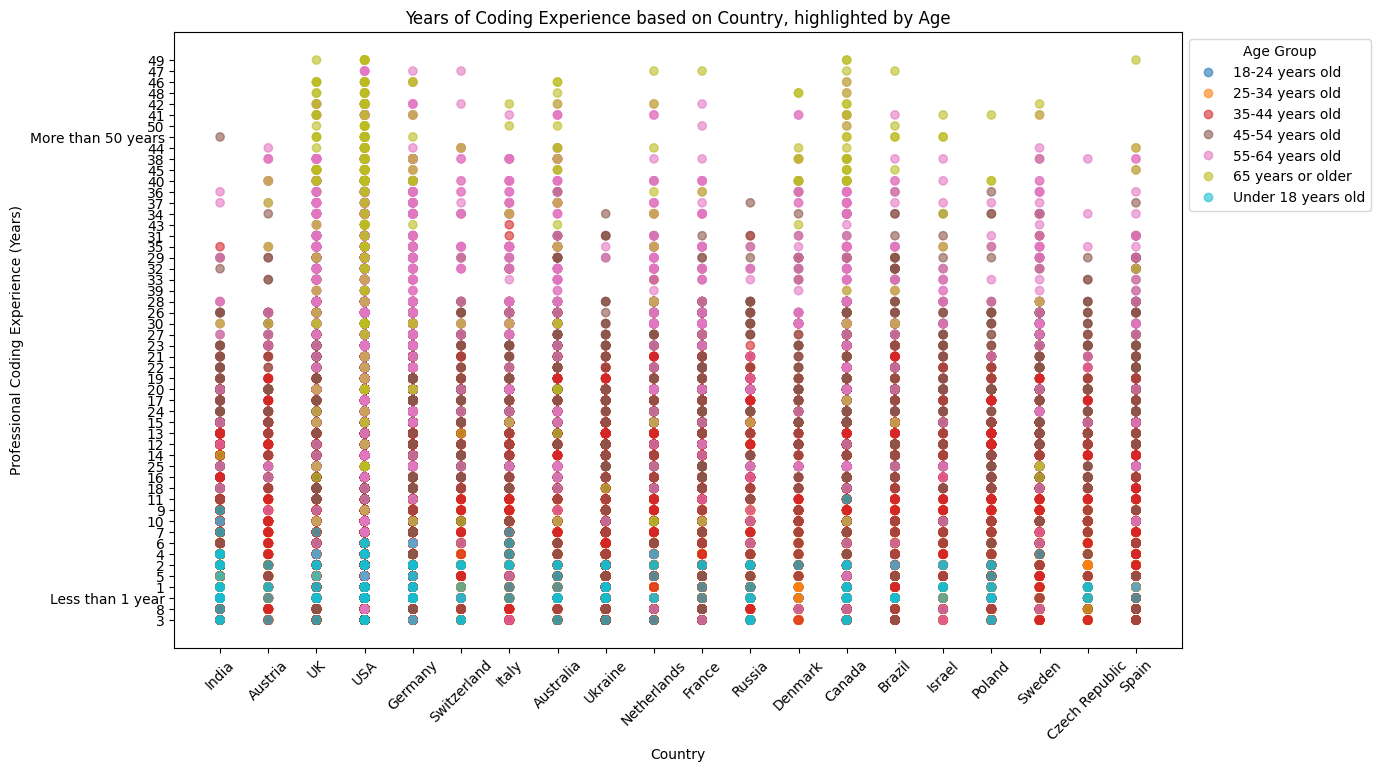

In [32]:
fig, ax = plt.subplots(figsize = (13, 8))
scatter = ax.scatter(x = scat_code_age['Country'],
                     y = scat_code_age['YearsCodePro'],
                     c = labels,
                     cmap = 'tab10',
                     alpha = 0.6)
ax.set_xlabel('Country')
ax.set_ylabel('Professional Coding Experience (Years)')
ax.set_title('Years of Coding Experience based on Country, highlighted by Age')
ax.tick_params(axis = 'x', labelrotation=45)
handles = scatter.legend_elements(num=[0, 1, 2, 3, 4, 5, 6])[0] # attain handles for legend
legend = ax.legend(*scatter.legend_elements(prop = 'colors')) # colors instead of size
ax.legend(title = 'Age Group',
          handles = handles,
          labels = legend_elements.keys(),
          bbox_to_anchor=(1, 1))
plt.show()

### Final Step: Review


With these scatter plots, you will have analyzed data relationships across multiple dimensions, including compensation, job satisfaction, employment types, and demographics, to uncover meaningful trends in the developer community.


### Summary


After completing this lab, you will be able to:
- Analyze how numerical variables relate across specific groups, such as employment types and countries.
- Use scatter plots effectively to represent multiple variables with color, size, and markers.
- Gain insights into compensation, satisfaction, and demographic trends using advanced scatter plot techniques.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


<!--## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|               
|2024-10-07|1.2|Madhusudan Moole|Reviewed and updated lab|                                                                                      
|2024-10-06|1.0|Raghul Ramesh|Created lab|-->


Copyright © IBM Corporation. All rights reserved.
